In [1]:
# ============================================================
# Housing Affordability DSS — Notebook 02: Feature Engineering
# CS7P01 MSc Project | London Metropolitan University
#
# Purpose: Build composite affordability index, risk
# classifications, regional rankings, and lag features
# that serve as inputs to the regression and forecasting
# models in notebooks 03 and 04.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
import os

warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':    (13, 6),
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'serif',
    'axes.titlepad':     14
})

PALETTE = [
    '#1F3864', '#2E5090', '#C0392B', '#27AE60', '#E67E22',
    '#8E44AD', '#2980B9', '#D35400', '#16A085', '#2C3E50'
]

# ── Paths ─────────────────────────────────────────────────────
PROCESSED = '../data/processed/'

# ── Load master dataset ───────────────────────────────────────
master = pd.read_csv(PROCESSED + 'master_affordability.csv')
master['year'] = master['year'].astype(int)

print(f"✓ Master dataset loaded")
print(f"  Shape      : {master.shape}")
print(f"  Year range : {master['year'].min()} → {master['year'].max()}")
print(f"  Regions    : {sorted(master['region'].unique())}")
print(f"  Columns    : {master.columns.tolist()}")

✓ Master dataset loaded
  Shape      : (290, 18)
  Year range : 1997 → 2025
  Regions    : ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'Wales', 'West Midlands Region', 'Yorkshire and The Humber']
  Columns    : ['year', 'affordability_ratio', 'region', 'avg_price_annual', 'avg_price_sa_annual', 'sales_volume_annual', 'index_sa_dec', 'affordability_ratio_lq', 'cpi_index', 'avg_weekly_earnings', 'avg_annual_earnings', 'real_house_price', 'real_annual_earnings', 'computed_ratio', 'ratio_gap', 'yoy_price_change_pct', 'yoy_ratio_change', 'high_stress']


In [2]:
# ============================================================
# CELL 2 — Composite Affordability Index (CAI)
#
# The CAI combines three measures into a single 0–100 score:
#   1. Median affordability ratio     (weight: 50%)
#   2. Lower quartile ratio           (weight: 30%)
#   3. Real house price normalised    (weight: 20%)
#
# ACADEMIC JUSTIFICATION:
# Gan and Hill (2009) show that median ratios alone mask
# distributional stress — combining median and lower quartile
# captures both typical and entry-level affordability.
# Real house price adds the absolute cost dimension that
# ratio measures alone cannot capture (Stone, 2006).
#
# Scaling to 0–100:
#   0  = most affordable observed across all regions/years
#   100 = least affordable observed
# This makes the index interpretable and comparable across
# regions regardless of underlying unit differences.
#
# We use only 2000–2025 where all three components are present.
# ============================================================

# ── Work on complete cases only (2000+) ──────────────────────
features = master[master['year'] >= 2000].copy()
features = features.sort_values(['region', 'year']).reset_index(drop=True)

# ── Components ───────────────────────────────────────────────
components = [
    'affordability_ratio',
    'affordability_ratio_lq',
    'real_house_price'
]

# Verify no missing values in components
missing = features[components].isnull().sum()
print("── Missing in components:")
print(missing)
assert missing.sum() == 0, "Fix missing values before indexing"

# ── Normalise each component to 0–100 using MinMaxScaler ─────
# MinMax scales relative to the observed min/max across ALL
# regions and years — so scores are comparable across regions
scaler = MinMaxScaler(feature_range=(0, 100))
scaled = scaler.fit_transform(features[components])
scaled_df = pd.DataFrame(
    scaled,
    columns=['ratio_scaled', 'ratio_lq_scaled', 'real_price_scaled']
)

# ── Weighted composite ────────────────────────────────────────
WEIGHTS = {
    'ratio_scaled':      0.50,   # Median ratio — primary measure
    'ratio_lq_scaled':   0.30,   # LQ ratio — distributional stress
    'real_price_scaled': 0.20    # Real price — absolute cost burden
}

features['cai'] = (
    scaled_df['ratio_scaled']      * WEIGHTS['ratio_scaled']      +
    scaled_df['ratio_lq_scaled']   * WEIGHTS['ratio_lq_scaled']   +
    scaled_df['real_price_scaled'] * WEIGHTS['real_price_scaled']
).round(2)

# Add scaled components for transparency
features['ratio_scaled']      = scaled_df['ratio_scaled'].round(2)
features['ratio_lq_scaled']   = scaled_df['ratio_lq_scaled'].round(2)
features['real_price_scaled'] = scaled_df['real_price_scaled'].round(2)

print(f"\n── CAI statistics:")
print(features.groupby('region')['cai'].agg(
    ['min', 'mean', 'max']
).round(2).sort_values('max', ascending=False).to_string())

── Missing in components:
affordability_ratio       0
affordability_ratio_lq    0
real_house_price          0
dtype: int64

── CAI statistics:
                            min   mean    max
region                                       
London                    26.72  67.69  99.20
South East                22.98  54.91  76.24
East of England           14.62  47.99  69.54
South West                16.10  46.76  63.86
East Midlands              5.18  30.01  45.45
West Midlands Region       7.06  30.45  43.30
Wales                      2.86  24.12  34.37
North West                 1.61  22.00  33.83
Yorkshire and The Humber   1.93  22.75  32.68
North East                 0.00  17.43  26.88


In [3]:
# ============================================================
# CELL 3 — Risk Classification
#
# Translates continuous CAI into four risk tiers.
# This is the decision logic layer of your DSS architecture.
#
# Thresholds are based on the ONS affordability benchmark
# (ratio > 5 = unaffordable) mapped onto the CAI scale,
# calibrated against the observed distribution:
#
#   Low      CAI < 25   — ratio typically below 5x
#   Medium   25 ≤ CAI < 50  — ratio typically 5x–7x
#   High     50 ≤ CAI < 75  — ratio typically 7x–10x
#   Critical CAI ≥ 75   — ratio typically above 10x
#
# Academic justification: threshold-based risk classification
# is consistent with Timmermans (1997) DSS design principles
# and Keen & Scott Morton (1978) semi-structured decision
# support framework — thresholds encode policy knowledge
# whilst the model supplies the analytical evidence.
# ============================================================

def classify_risk(cai):
    if cai < 25:
        return 'Low'
    elif cai < 50:
        return 'Medium'
    elif cai < 75:
        return 'High'
    else:
        return 'Critical'

features['risk_class'] = features['cai'].apply(classify_risk)

# Ordered category for sorting
RISK_ORDER = ['Low', 'Medium', 'High', 'Critical']
features['risk_class'] = pd.Categorical(
    features['risk_class'],
    categories=RISK_ORDER,
    ordered=True
)


# ── Distribution of risk classes ─────────────────────────────
risk_dist = (features
             .groupby(['region', 'risk_class'], observed=True)
             .size()
             .unstack(fill_value=0))

print("── Risk class distribution (years per class per region):")
print(risk_dist.to_string())

print(f"\n── Overall distribution:")
print(features['risk_class'].value_counts().sort_index().to_string())

# ── Latest year risk snapshot ─────────────────────────────────
latest = features[features['year'] == features['year'].max()].copy()
latest_risk = (latest[['region', 'affordability_ratio', 'cai', 'risk_class']]
               .sort_values('cai', ascending=False))
print(f"\n── Risk snapshot — {features['year'].max()}:")
print(latest_risk.to_string(index=False))

── Risk class distribution (years per class per region):
risk_class                Low  Medium  High  Critical
region                                               
East Midlands               5      21     0         0
East of England             2      13    11         0
London                      0       6     9        11
North East                 24       2     0         0
North West                 14      12     0         0
South East                  1       8    16         1
South West                  2      14    10         0
Wales                       9      17     0         0
West Midlands Region        4      22     0         0
Yorkshire and The Humber   12      14     0         0

── Overall distribution:
risk_class
Low          73
Medium      129
High         46
Critical     12

── Risk snapshot — 2025:
                  region  affordability_ratio   cai risk_class
                  London                10.61 78.13   Critical
              South East                 9

In [4]:
# ============================================================
# CELL 4 — Lag features
#
# Lag features capture temporal dependencies — the idea that
# this year's affordability is partly determined by last
# year's conditions. These become independent variables
# in the OLS regression model (notebook 03).
#
# Features engineered:
#   ratio_lag1    — prior year affordability ratio
#   ratio_lag2    — two years prior
#   ratio_ma3     — 3-year moving average (smooths noise)
#   ratio_ma5     — 5-year moving average (longer trend)
#   price_lag1    — prior year house price
#   ratio_pct_chg — percentage change in ratio year-on-year
#   above_thresh  — binary: ratio > 5 (ONS threshold)
#   years_above   — consecutive years above threshold
# ============================================================

features = features.sort_values(['region', 'year'])

# Lag 1 and lag 2
features['ratio_lag1'] = features.groupby('region')['affordability_ratio'].shift(1)
features['ratio_lag2'] = features.groupby('region')['affordability_ratio'].shift(2)

# Moving averages
features['ratio_ma3'] = (features
                          .groupby('region')['affordability_ratio']
                          .transform(lambda x: x.rolling(3, min_periods=3).mean())
                          .round(3))

features['ratio_ma5'] = (features
                          .groupby('region')['affordability_ratio']
                          .transform(lambda x: x.rolling(5, min_periods=5).mean())
                          .round(3))

# Price lag
features['price_lag1'] = features.groupby('region')['avg_price_annual'].shift(1)

# Ratio percentage change
features['ratio_pct_chg'] = (
    features.groupby('region')['affordability_ratio']
    .pct_change() * 100
).round(3)

# Binary: above ONS threshold
features['above_thresh'] = (features['affordability_ratio'] >= 5).astype(int)

# Consecutive years above threshold
def consecutive_above(series):
    result = []
    count = 0
    for val in series:
        if val >= 5:
            count += 1
        else:
            count = 0
        result.append(count)
    return result

features['years_above'] = features.groupby('region')['affordability_ratio'].transform(
    consecutive_above
)

print(f"── Feature engineering complete")
print(f"── Shape now : {features.shape}")
print(f"\n── New features:")
new_feats = ['ratio_lag1', 'ratio_lag2', 'ratio_ma3', 'ratio_ma5',
             'price_lag1', 'ratio_pct_chg', 'above_thresh', 'years_above']
print(features[new_feats].describe().round(2).to_string())

print(f"\n── Missing values in new features (expected for early years):")
print(features[new_feats].isnull().sum().to_string())

── Feature engineering complete
── Shape now : (260, 31)

── New features:
       ratio_lag1  ratio_lag2  ratio_ma3  ratio_ma5  price_lag1  ratio_pct_chg  above_thresh  years_above
count      250.00      240.00     240.00     220.00      250.00         250.00        260.00       260.00
mean         6.74        6.70       6.85       6.90   186031.00           2.76          0.90        10.95
std          1.99        1.99       1.91       1.83    99878.75           6.80          0.31         7.49
min          2.98        2.98       3.10       3.60    46652.75         -11.44          0.00         0.00
25%          5.54        5.49       5.60       5.63   123920.62          -1.81          1.00         4.00
50%          6.22        6.20       6.26       6.24   153727.45           1.76          1.00        11.00
75%          7.83        7.82       7.86       7.92   221737.94           6.39          1.00        17.00
max         12.86       12.86      12.36      12.28   565955.42          25.9

In [5]:
# ============================================================
# CELL 5 — Regional ranking by CAI
#
# Ranks regions from least to most affordable each year.
# Rank 1 = least affordable, Rank 10 = most affordable.
# Tracking rank changes over time reveals which regions
# are deteriorating fastest relative to others.
# ============================================================


features['risk_rank'] = (features
                          .groupby('year')['cai']
                          .rank(ascending=False, method='min')
                          .astype(int))

# Show rank changes for key years
rank_pivot = features.pivot(
    index='region',
    columns='year',
    values='risk_rank'
)

# Show subset of years for readability
key_years = [2000, 2005, 2010, 2015, 2020, 2025]
key_years = [y for y in key_years if y in rank_pivot.columns]

print("── Regional Risk Ranking Over Time (1=least affordable, 10=most):")
print(rank_pivot[key_years].to_string())

print(f"\n── Rank in 2025 (1=least affordable):")
rank_2025 = (features[features['year']==2025]
             [['region','cai','affordability_ratio','risk_class','risk_rank']]
             .sort_values('risk_rank'))
print(rank_2025.to_string(index=False))

── Regional Risk Ranking Over Time (1=least affordable, 10=most):
year                      2000  2005  2010  2015  2020  2025
region                                                      
East Midlands                6     6     6     5     5     5
East of England              4     4     4     3     3     3
London                       1     1     1     1     1     1
North East                  10    10    10    10    10    10
North West                   9     9     9     9     9     9
South East                   2     2     2     2     2     2
South West                   3     3     3     4     4     4
Wales                        7     7     7     7     7     8
West Midlands Region         5     5     5     6     6     6
Yorkshire and The Humber     8     8     8     8     8     7

── Rank in 2025 (1=least affordable):
                  region   cai  affordability_ratio risk_class  risk_rank
                  London 78.13                10.61   Critical          1
              S

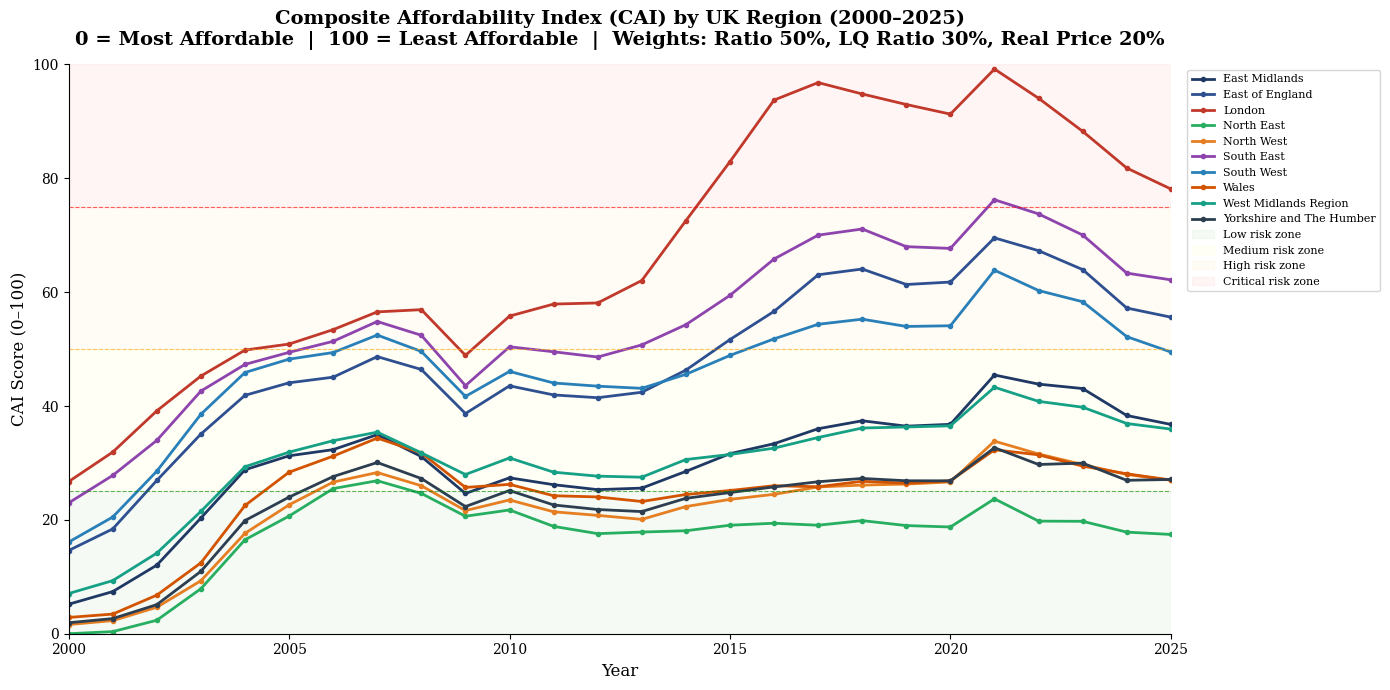

✓ Plot 8 saved


In [6]:
# ============================================================
# CELL 6 — Plot 8: Composite Affordability Index over time
#
# This is the key visualisation from your feature engineering.
# Unlike the raw ratio, the CAI integrates three dimensions
# of affordability stress into a single trackable score.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

for i, region in enumerate(sorted(features['region'].unique())):
    data = features[features['region'] == region].sort_values('year')
    ax.plot(
        data['year'], data['cai'],
        label=region, color=PALETTE[i],
        linewidth=2, marker='o', markersize=3
    )

# Risk tier bands
ax.axhspan(0,  25, alpha=0.04, color='green',  label='Low risk zone')
ax.axhspan(25, 50, alpha=0.04, color='yellow', label='Medium risk zone')
ax.axhspan(50, 75, alpha=0.04, color='orange', label='High risk zone')
ax.axhspan(75, 100,alpha=0.04, color='red',    label='Critical risk zone')

# Threshold lines
for threshold, label, color in [(25,'Low→Medium','green'),
                                 (50,'Medium→High','orange'),
                                 (75,'High→Critical','red')]:
    ax.axhline(y=threshold, color=color, linestyle='--',
               linewidth=0.8, alpha=0.6)

ax.set_title(
    'Composite Affordability Index (CAI) by UK Region (2000–2025)\n'
    '0 = Most Affordable  |  100 = Least Affordable  |  '
    'Weights: Ratio 50%, LQ Ratio 30%, Real Price 20%',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('CAI Score (0–100)')
ax.set_xlim(2000, 2025)
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED + 'plot8_cai_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 8 saved")

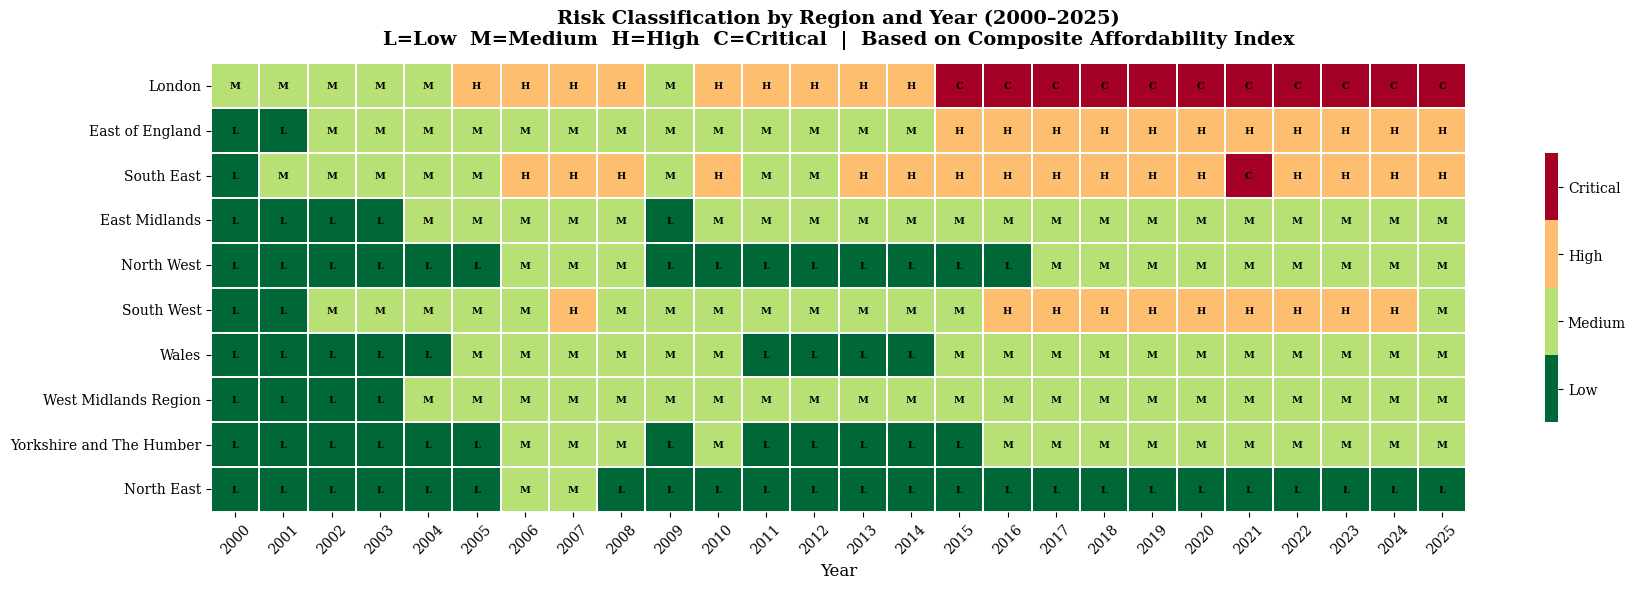

✓ Plot 9 saved


In [9]:
# ============================================================
# CELL 7 — Plot 9: Risk classification heatmap
#
# Shows when each region entered each risk tier.
# More intuitive for policymakers than raw numbers.
# This is your decision logic layer visualised.
# ============================================================

# ── Convert to string first to avoid Categorical TypeError ───
risk_map   = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

risk_pivot = features.pivot(
    index='region',
    columns='year',
    values='risk_class'
)

# Convert Categorical → string → int via map
risk_pivot_str     = risk_pivot.astype(str)
risk_pivot_str.columns = risk_pivot_str.columns.astype(int)
risk_numeric       = risk_pivot_str.apply(
    lambda col: col.map(risk_map)
)

# Sort by 2025 risk level — most at risk at top
sort_order   = risk_numeric[2025].sort_values(ascending=False).index
risk_numeric = risk_numeric.loc[sort_order]
risk_pivot_str = risk_pivot_str.loc[sort_order]

fig, ax = plt.subplots(figsize=(18, 6))
cmap = plt.cm.get_cmap('RdYlGn_r', 4)

sns.heatmap(
    risk_numeric,
    cmap=cmap,
    vmin=0.5, vmax=4.5,
    ax=ax,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'ticks': [1, 2, 3, 4], 'shrink': 0.6}
)

# Add text labels — L, M, H, C
for y_idx in range(len(risk_pivot_str.index)):
    for x_idx in range(len(risk_pivot_str.columns)):
        val = risk_pivot_str.iloc[y_idx, x_idx]
        if val not in ['nan', 'None', '']:
            short = val[0]  # L, M, H, C
            ax.text(
                x_idx + 0.5, y_idx + 0.5, short,
                ha='center', va='center',
                fontsize=7, fontweight='bold',
                color='black'
            )

colorbar = ax.collections[0].colorbar
colorbar.set_ticklabels(['Low', 'Medium', 'High', 'Critical'])

ax.set_title(
    'Risk Classification by Region and Year (2000–2025)\n'
    'L=Low  M=Medium  H=High  C=Critical  |  Based on Composite Affordability Index',
    fontweight='bold'
)
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PROCESSED + 'plot9_risk_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 9 saved")

In [8]:
# ============================================================
# CELL 8 — Save enriched feature dataset
# ============================================================

features.to_csv(PROCESSED + 'features_engineered.csv', index=False)

print("✓ features_engineered.csv saved")
print(f"  Shape      : {features.shape}")
print(f"  Year range : {features['year'].min()} → {features['year'].max()}")
print(f"  Columns    : {features.columns.tolist()}")

print(f"""
── Feature summary:
   Core affordability   : affordability_ratio, affordability_ratio_lq
   Real terms           : real_house_price, real_annual_earnings
   Composite index      : cai (0–100 score)
   Risk classification  : risk_class (Low/Medium/High/Critical)
   Regional ranking     : risk_rank (1=most affordable)
   Lag features         : ratio_lag1, ratio_lag2, price_lag1
   Moving averages      : ratio_ma3, ratio_ma5
   Change indicators    : ratio_pct_chg, yoy_price_change_pct
   Binary flags         : above_thresh, high_stress, years_above
""")

✓ features_engineered.csv saved
  Shape      : (260, 32)
  Year range : 2000 → 2025
  Columns    : ['year', 'affordability_ratio', 'region', 'avg_price_annual', 'avg_price_sa_annual', 'sales_volume_annual', 'index_sa_dec', 'affordability_ratio_lq', 'cpi_index', 'avg_weekly_earnings', 'avg_annual_earnings', 'real_house_price', 'real_annual_earnings', 'computed_ratio', 'ratio_gap', 'yoy_price_change_pct', 'yoy_ratio_change', 'high_stress', 'cai', 'ratio_scaled', 'ratio_lq_scaled', 'real_price_scaled', 'risk_class', 'ratio_lag1', 'ratio_lag2', 'ratio_ma3', 'ratio_ma5', 'price_lag1', 'ratio_pct_chg', 'above_thresh', 'years_above', 'risk_rank']

── Feature summary:
   Core affordability   : affordability_ratio, affordability_ratio_lq
   Real terms           : real_house_price, real_annual_earnings
   Composite index      : cai (0–100 score)
   Risk classification  : risk_class (Low/Medium/High/Critical)
   Regional ranking     : risk_rank (1=most affordable)
   Lag features         : ratio_